In [20]:
from hossam import *

from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
import datetime as dt
from pandas import to_datetime, DataFrame, date_range, concat
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from sklearn.metrics import mean_absolute_error, mean_squared_error
import holidays

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid

from tqdm.auto import tqdm

import pyupbit

In [21]:
print(pyupbit.get_tickers())

['BTC-BERA', 'BTC-FIL', 'BTC-SIGN', 'BTC-VIRTUAL', 'BTC-BAT', 'KRW-WAXP', 'USDT-PEPE', 'BTC-BAR', 'USDT-WCT', 'KRW-CARV', 'KRW-LSK', 'USDT-DOGE', 'KRW-0G', 'USDT-AXL', 'USDT-YGG', 'BTC-SCR', 'USDT-JASMY', 'BTC-WLD', 'BTC-VANA', 'BTC-LWA', 'BTC-DGB', 'USDT-BONK', 'BTC-BCH', 'BTC-JASMY', 'KRW-BORA', 'KRW-PUNDIX', 'BTC-ORBS', 'USDT-WAL', 'KRW-USD1', 'USDT-WLFI', 'KRW-BAT', 'USDT-ZK', 'USDT-NOM', 'KRW-HUNT', 'KRW-PENGU', 'KRW-FIL', 'BTC-ANIME', 'BTC-ORCA', 'KRW-BEAM', 'BTC-SOON', 'BTC-ELSA', 'BTC-LRC', 'KRW-DOOD', 'BTC-TOKAMAK', 'BTC-SOPH', 'BTC-STRAX', 'KRW-WAVES', 'KRW-USDC', 'KRW-MOVE', 'KRW-TREE', 'BTC-GLMR', 'KRW-USDE', 'KRW-AERGO', 'KRW-WET', 'KRW-USDT', 'BTC-LSK', 'USDT-RENDER', 'BTC-SOMI', 'USDT-RESOLV', 'KRW-2Z', 'BTC-STEEM', 'USDT-LPT', 'KRW-BOUNTY', 'KRW-KAITO', 'USDT-WET', 'KRW-LPT', 'BTC-PROVE', 'BTC-DEEP', 'BTC-WET', 'USDT-ARPA', 'BTC-INIT', 'BTC-LPT', 'BTC-BREV', 'BTC-POLYX', 'KRW-BLAST', 'USDT-ANIME', 'USDT-USDE', 'USDT-USDC', 'USDT-TREE', 'BTC-BIO', 'USDT-WLD', 'BTC-BIRB',

In [22]:
print(pyupbit.get_tickers(fiat="KRW"))

['KRW-WAXP', 'KRW-CARV', 'KRW-LSK', 'KRW-0G', 'KRW-BORA', 'KRW-PUNDIX', 'KRW-USD1', 'KRW-BAT', 'KRW-HUNT', 'KRW-PENGU', 'KRW-FIL', 'KRW-BEAM', 'KRW-DOOD', 'KRW-WAVES', 'KRW-USDC', 'KRW-MOVE', 'KRW-TREE', 'KRW-USDE', 'KRW-AERGO', 'KRW-WET', 'KRW-USDT', 'KRW-2Z', 'KRW-BOUNTY', 'KRW-KAITO', 'KRW-LPT', 'KRW-BLAST', 'KRW-DKA', 'KRW-ANKR', 'KRW-ALGO', 'KRW-SHIB', 'KRW-UNI', 'KRW-BIO', 'KRW-WLFI', 'KRW-TOKAMAK', 'KRW-CYBER', 'KRW-SKR', 'KRW-DOGE', 'KRW-WLD', 'KRW-PEPE', 'KRW-HBAR', 'KRW-BCH', 'KRW-NEWT', 'KRW-SEI', 'KRW-BONK', 'KRW-JST', 'KRW-AAVE', 'KRW-JTO', 'KRW-JUP', 'KRW-FLOW', 'KRW-ALT', 'KRW-LAYER', 'KRW-TRX', 'KRW-POWR', 'KRW-ATOM', 'KRW-ARKM', 'KRW-CRO', 'KRW-NXPC', 'KRW-A', 'KRW-TRUMP', 'KRW-F', 'KRW-G', 'KRW-CELO', 'KRW-AERO', 'KRW-CTC', 'KRW-ANIME', 'KRW-APT', 'KRW-MOCA', 'KRW-API3', 'KRW-AHT', 'KRW-EGLD', 'KRW-ERA', 'KRW-FF', 'KRW-PLUME', 'KRW-ESP', 'KRW-NEO', 'KRW-ETC', 'KRW-IOTA', 'KRW-IOST', 'KRW-AKT', 'KRW-COW', 'KRW-VIRTUAL', 'KRW-ETH', 'KRW-IQ', 'KRW-IP', 'KRW-NEAR', 'KRW-R

In [23]:
pyupbit.get_current_price(["KRW-BTC", "KRW-ETH"])

{'KRW-BTC': 96451000.0, 'KRW-ETH': 2799000.0}

In [24]:
ticker = "KRW-BTC"

to = dt.datetime.now().strftime("%Y-%m-%d")

count = 365

interval = "day"

origin = pyupbit.get_ohlcv(ticker=ticker, interval=interval, to=to, count=count)
origin.head()

,open,high,low,close,volume,value
2025-02-25 09:00:00,132135000.000,134899000.000,125004000.000,129715000.000,9063.168,1173142441896.490
2025-02-26 09:00:00,129715000.000,130000000.000,120723000.000,122784000.000,4911.988,616121443775.913
2025-02-27 09:00:00,122775000.000,127493000.000,121500000.000,124331000.000,3832.783,477534913336.857
2025-02-28 09:00:00,124404000.000,125411000.000,116504000.000,124499000.000,8051.742,968879646102.795
2025-03-01 09:00:00,124499000.000,128980000.000,123342000.000,128320000.000,3200.778,405122480757.343


In [25]:
df1 = origin.copy()
df1["price"] = (df1["high"] + df1["low"]) / 2
df1.head()

,open,high,low,close,volume,value,price
2025-02-25 09:00:00,132135000.000,134899000.000,125004000.000,129715000.000,9063.168,1173142441896.490,129951500.000
2025-02-26 09:00:00,129715000.000,130000000.000,120723000.000,122784000.000,4911.988,616121443775.913,125361500.000
2025-02-27 09:00:00,122775000.000,127493000.000,121500000.000,124331000.000,3832.783,477534913336.857,124496500.000
2025-02-28 09:00:00,124404000.000,125411000.000,116504000.000,124499000.000,8051.742,968879646102.795,120957500.000
2025-03-01 09:00:00,124499000.000,128980000.000,123342000.000,128320000.000,3200.778,405122480757.343,126161000.000


In [26]:
df2 = df1[["price"]].copy()
df2.reset_index(inplace=True)
df2.rename(columns={"index": "ds", "price": "y"}, inplace=True)
df2.head()

,ds,y
0,2025-02-25 09:00:00,129951500.000
1,2025-02-26 09:00:00,125361500.000
2,2025-02-27 09:00:00,124496500.000
3,2025-02-28 09:00:00,120957500.000
4,2025-03-01 09:00:00,126161000.000


In [27]:
# 분할 비율
split_ratio = 0.8

# 분할 인덱스
split_idx = int(len(df2) * split_ratio)

# 훈련 / 검증 데이터
train = df2.iloc[:split_idx]
test = df2.iloc[split_idx:]

print("Train 기간:", train["ds"].min(), "~", train["ds"].max())
print("Valid 기간:", test["ds"].min(), "~", test["ds"].max())

Train 기간: 2025-02-25 09:00:00 ~ 2025-12-13 09:00:00
Valid 기간: 2025-12-14 09:00:00 ~ 2026-02-24 09:00:00


In [28]:
start_date = train["ds"].min()
end_date = test["ds"].max()

# 주말 데이터
sat = date_range(start=start_date, end=end_date, freq="W-SAT")
sun = date_range(start=start_date, end=end_date, freq="W-SUN")

weekend = sat.union(sun)
df_weekend = DataFrame(
    {
        "holiday": "weekend",
        "ds": weekend.sort_values(),
        "lower_window": 0,
        "upper window": 0,
    }
)
df_weekend.head()

,holiday,ds,lower_window,upper window
0,weekend,2025-03-01 09:00:00,0,0
1,weekend,2025-03-02 09:00:00,0,0
2,weekend,2025-03-08 09:00:00,0,0
3,weekend,2025-03-09 09:00:00,0,0
4,weekend,2025-03-15 09:00:00,0,0


In [29]:
years = list(range(to_datetime(start_date).year, to_datetime(end_date).year + 1))
kr = holidays.KR(years=years)
hd_dict = {"holiday": [], "ds": [], "lower_window": [], "upper_window": []}
for date, name in kr.items():
    hd_dict["holiday"].append(name)
    hd_dict["ds"].append(date)
    hd_dict["lower_window"].append(0)
    hd_dict["upper_window"].append(0)
df_holidays = DataFrame(hd_dict)
df_holidays["ds"] = to_datetime(df_holidays["ds"])
df_holidays.sort_values("ds", inplace=True)
df_holidays.head()

,holiday,ds,lower_window,upper_window
0,New Year's Day,2025-01-01,0,0
17,Temporary Public Holiday,2025-01-27,0,0
2,The day preceding Korean New Year,2025-01-28,0,0
1,Korean New Year,2025-01-29,0,0
3,The second day of Korean New Year,2025-01-30,0,0


In [30]:
holydays_final = concat([df_weekend, df_holidays], ignore_index=True)

holydays_final.sort_values("ds", inplace=True)

holydays_final.reset_index(drop=True, inplace=True)
holydays_final.head(10)

,holiday,ds,lower_window,upper window,upper_window
0,New Year's Day,2025-01-01 00:00:00,0,NaN,0.000
1,Temporary Public Holiday,2025-01-27 00:00:00,0,NaN,0.000
2,The day preceding Korean New Year,2025-01-28 00:00:00,0,NaN,0.000
3,Korean New Year,2025-01-29 00:00:00,0,NaN,0.000
4,The second day of Korean New Year,2025-01-30 00:00:00,0,NaN,0.000
5,Independence Movement Day,2025-03-01 00:00:00,0,NaN,0.000
6,weekend,2025-03-01 09:00:00,0,0.000,NaN
7,weekend,2025-03-02 09:00:00,0,0.000,NaN
8,Alternative holiday for Independence Movement Day,2025-03-03 00:00:00,0,NaN,0.000
9,weekend,2025-03-08 09:00:00,0,0.000,NaN


In [31]:
mask = (holydays_final["ds"] >= start_date) & (holydays_final["ds"] <= end_date)
holydays_final = holydays_final.loc[mask].reset_index(drop=True)
holydays_final.head()

,holiday,ds,lower_window,upper window,upper_window
0,Independence Movement Day,2025-03-01 00:00:00,0,NaN,0.000
1,weekend,2025-03-01 09:00:00,0,0.000,NaN
2,weekend,2025-03-02 09:00:00,0,0.000,NaN
3,Alternative holiday for Independence Movement Day,2025-03-03 00:00:00,0,NaN,0.000
4,weekend,2025-03-08 09:00:00,0,0.000,NaN


In [32]:
params = ParameterGrid(
    {
        "growth": ["linear"],
        "changepoint_prior_scale": [0.01, 0.1, 1.0],
        "seasonality_mode": ["additive", "multiplicative"],
        "yearly_seasonality": [True],
        "weekly_seasonality": [True],
        "daily_seasonality": [False],
        "holidays": [holydays_final],
    }
)

print("Total Possible Models", len(params))

Total Possible Models 6


In [33]:
%%time

import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

result = []

with tqdm(total=len(params)) as pbar:
    for i, p in enumerate(params):

        pbar.set_description(f"Model {i+1}/{len(params)}")

        m = Prophet(**p)
        m.fit(train)

        future = m.make_future_dataframe(periods=len(test), freq='D')
        forecast = m.predict(future)

        pred = forecast[['ds', 'yhat']][-len(test):]
        score = np.sqrt(mean_squared_error(test['y'].values, pred['yhat'].values))

        result.append({
            "score": score,
            "model": m,
            "params": p,
        })

        pbar.update(1)

# result 배열에서 score가 가장 좋은 모델을 찾는다.
# RMSE가 가장 낮은 모델이 가장 좋은 모델이므로, score가 가장 작은 모델을 찾는다.
best_index = min(result, key=lambda x: x['score'])
best_model = best_index['model']
best_params = best_index['params']
best_score = best_index['score']

print("Best Score (RMSE):", best_score)
print("Best Parameters:", best_params)

  0%|          | 0/6 [00:00<?, ?it/s]

Best Score (RMSE): 26358772.55181766
Best Parameters: {'changepoint_prior_scale': 0.01, 'daily_seasonality': False, 'growth': 'linear', 'holidays':                                                holiday                  ds  \
0                            Independence Movement Day 2025-03-01 00:00:00   
1                                              weekend 2025-03-01 09:00:00   
2                                              weekend 2025-03-02 09:00:00   
3    Alternative holiday for Independence Movement Day 2025-03-03 00:00:00   
4                                              weekend 2025-03-08 09:00:00   
..                                                 ...                 ...   
117                  The day preceding Korean New Year 2026-02-16 00:00:00   
118                                    Korean New Year 2026-02-17 00:00:00   
119                  The second day of Korean New Year 2026-02-18 00:00:00   
120                                            weekend 2026-02-21 09:00:

In [34]:
# 실제 예측 데이터보다 7단계 더 미래까지 예측해보자. (1주일)
future = best_model.make_future_dataframe(periods=len(test) + 7, freq="D")
forecast = best_model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Alternative holiday for Buddha's Birthday; Alternative holiday for Children's Day,Alternative holiday for Buddha's Birthday; Alternative holiday for Children's Day_lower,Alternative holiday for Buddha's Birthday; Alternative holiday for Children's Day_upper,Alternative holiday for Chuseok,Alternative holiday for Chuseok_lower,Alternative holiday for Chuseok_upper,Alternative holiday for Independence Movement Day,Alternative holiday for Independence Movement Day_lower,Alternative holiday for Independence Movement Day_upper,Buddha's Birthday; Children's Day,Buddha's Birthday; Children's Day_lower,Buddha's Birthday; Children's Day_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Chuseok,Chuseok_lower,Chuseok_upper,Hangul Day,Hangul Day_lower,Hangul Day_upper,Independence Movement Day,Independence Movement Day_lower,Independence Movement Day_upper,Korean New Year,Korean New Year_lower,Korean New Year_upper,Liberation Day,Liberation Day_lower,Liberation Day_upper,Memorial Day,Memorial Day_lower,Memorial Day_upper,National Foundation Day,National Foundation Day_lower,National Foundation Day_upper,New Year's Day,New Year's Day_lower,New Year's Day_upper,Presidential Election Day,Presidential Election Day_lower,Presidential Election Day_upper,The day preceding Chuseok,The day preceding Chuseok_lower,The day preceding Chuseok_upper,The day preceding Korean New Year,The day preceding Korean New Year_lower,The day preceding Korean New Year_upper,The second day of Chuseok,The second day of Chuseok_lower,The second day of Chuseok_upper,The second day of Korean New Year,The second day of Korean New Year_lower,The second day of Korean New Year_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,holidays_lower,holidays_upper,weekend,weekend_lower,weekend_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-02-25 09:00:00,138570700.316,125358748.928,133348381.815,138570700.316,138570700.316,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-9217944.123,-9217944.123,-9217944.123,0.000,0.000,0.000,0.000,0.000,0.000,388765.012,388765.012,388765.012,-9606709.135,-9606709.135,-9606709.135,0.000,0.000,0.000,129352756.193
1,2025-02-26 09:00:00,138609056.108,125442515.668,133179136.423,138609056.108,138609056.108,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-9484814.430,-9484814.430,-9484814.430,0.000,0.000,0.000,0.000,0.000,0.000,615988.157,615988.157,615988.157,-10100802.587,-10100802.587,-10100802.587,0.000,0.000,0.000,129124241.678
2,2025-02-27 09:00:00,138647411.900,125149057.482,133167772.005,138647411.900,138647411.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-9651981.687,-9651981.687,-9651981.687,0.000,0.000,0.000,0.000,0.000,0.000,940024.333,940024.333,940024.333,-10592006.019,-10592006.019,-10592006.019,0.000,0.000,0.000,128995430.213
3,2025-02-28 09:00:00,138685767.692,124327676.584,131599047.973,138685767.692,138685767.692,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0

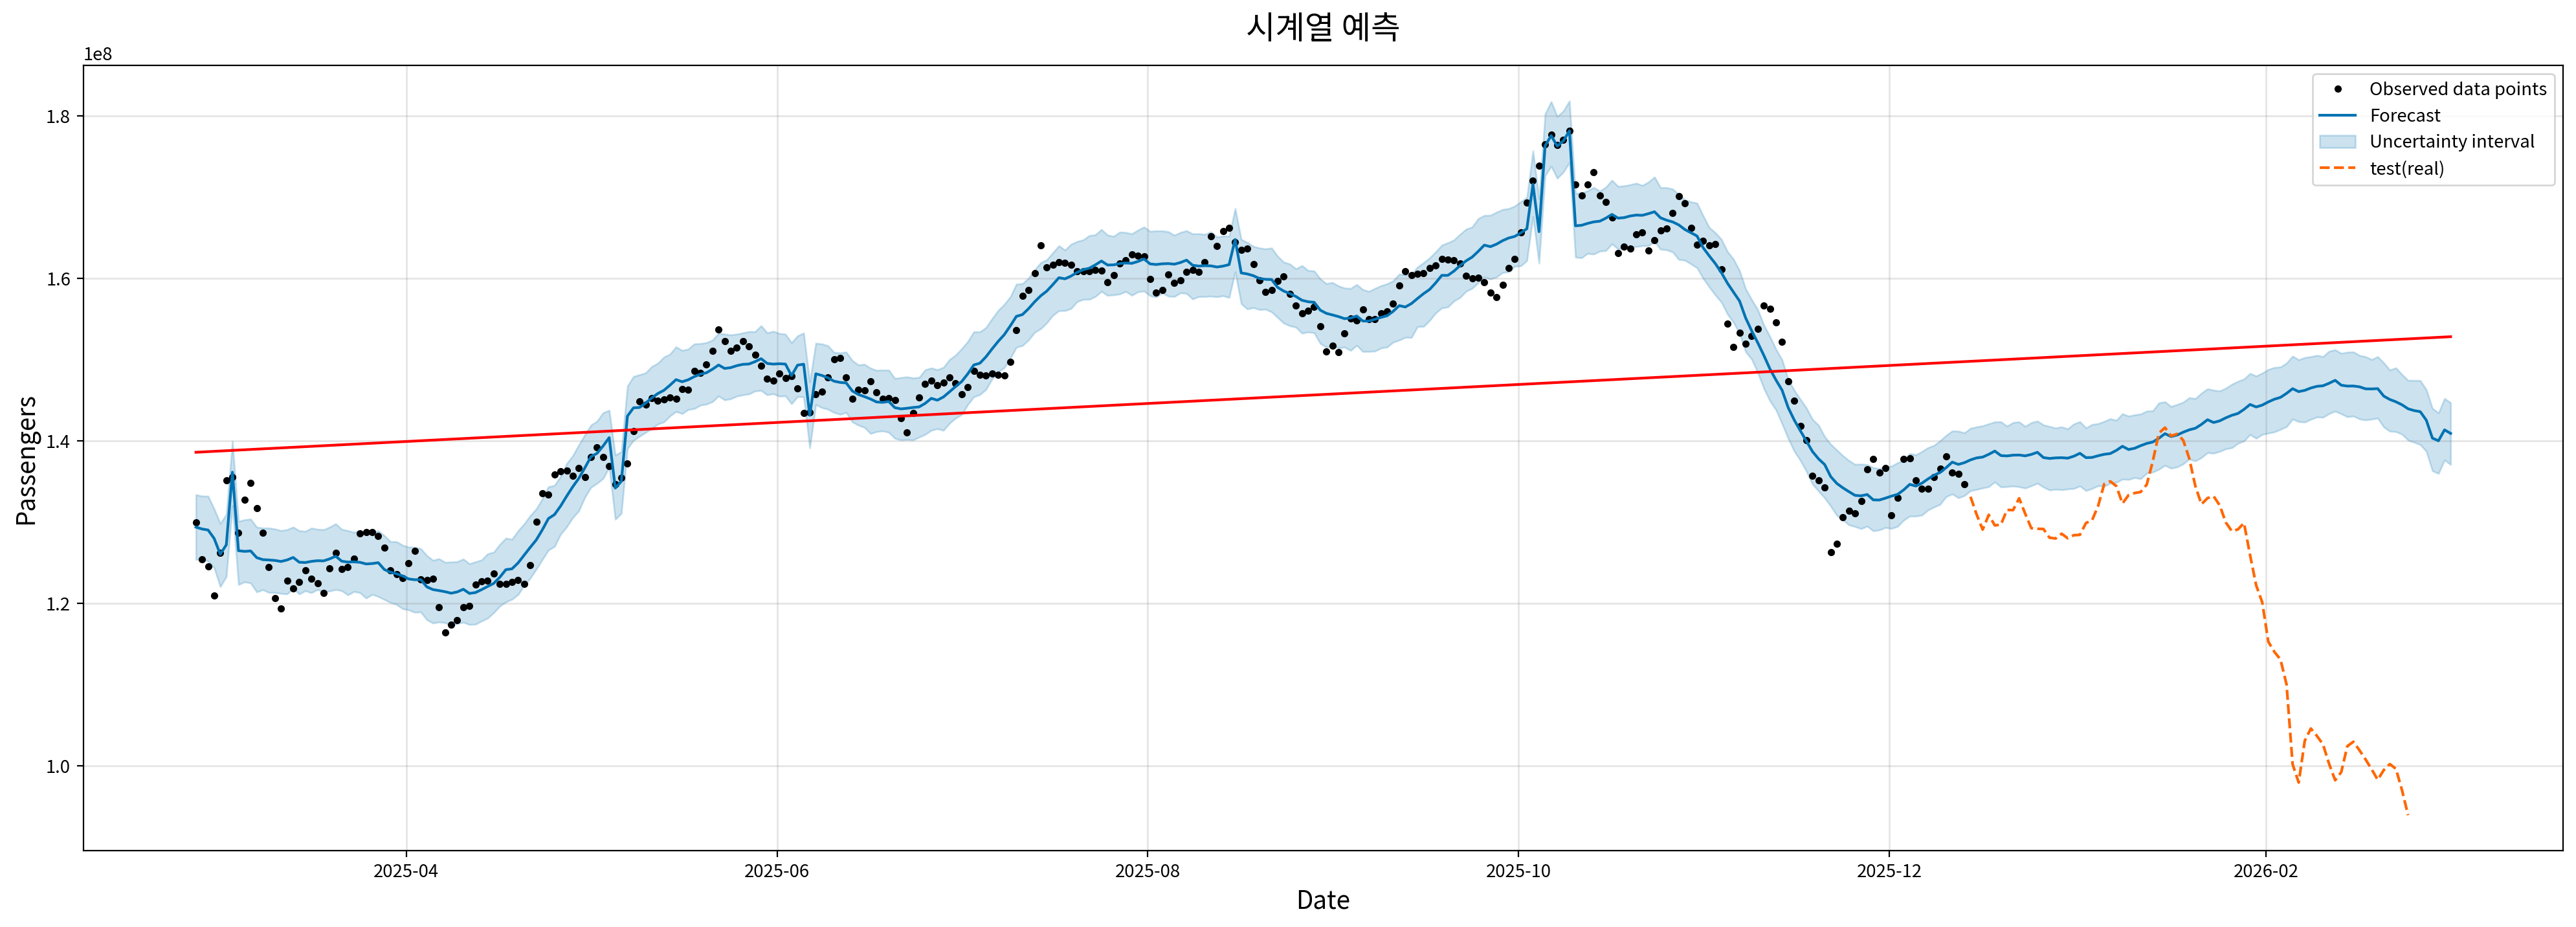

In [35]:
fig = best_model.plot(
    forecast, figsize=(20, 7), xlabel="Date", ylabel="Passengers", uncertainty=True
)
ax = fig.gca()
add_changepoints_to_plot(ax, best_model, forecast)
ax.set_title("시계열 예측")

# 실제 검증 데이터는 직접 추가한다.
sb.lineplot(
    data=test, x="ds", y="y", ax=ax, color="#ff6600", linestyle="--", label="test(real)"
)

plt.show()
plt.close()

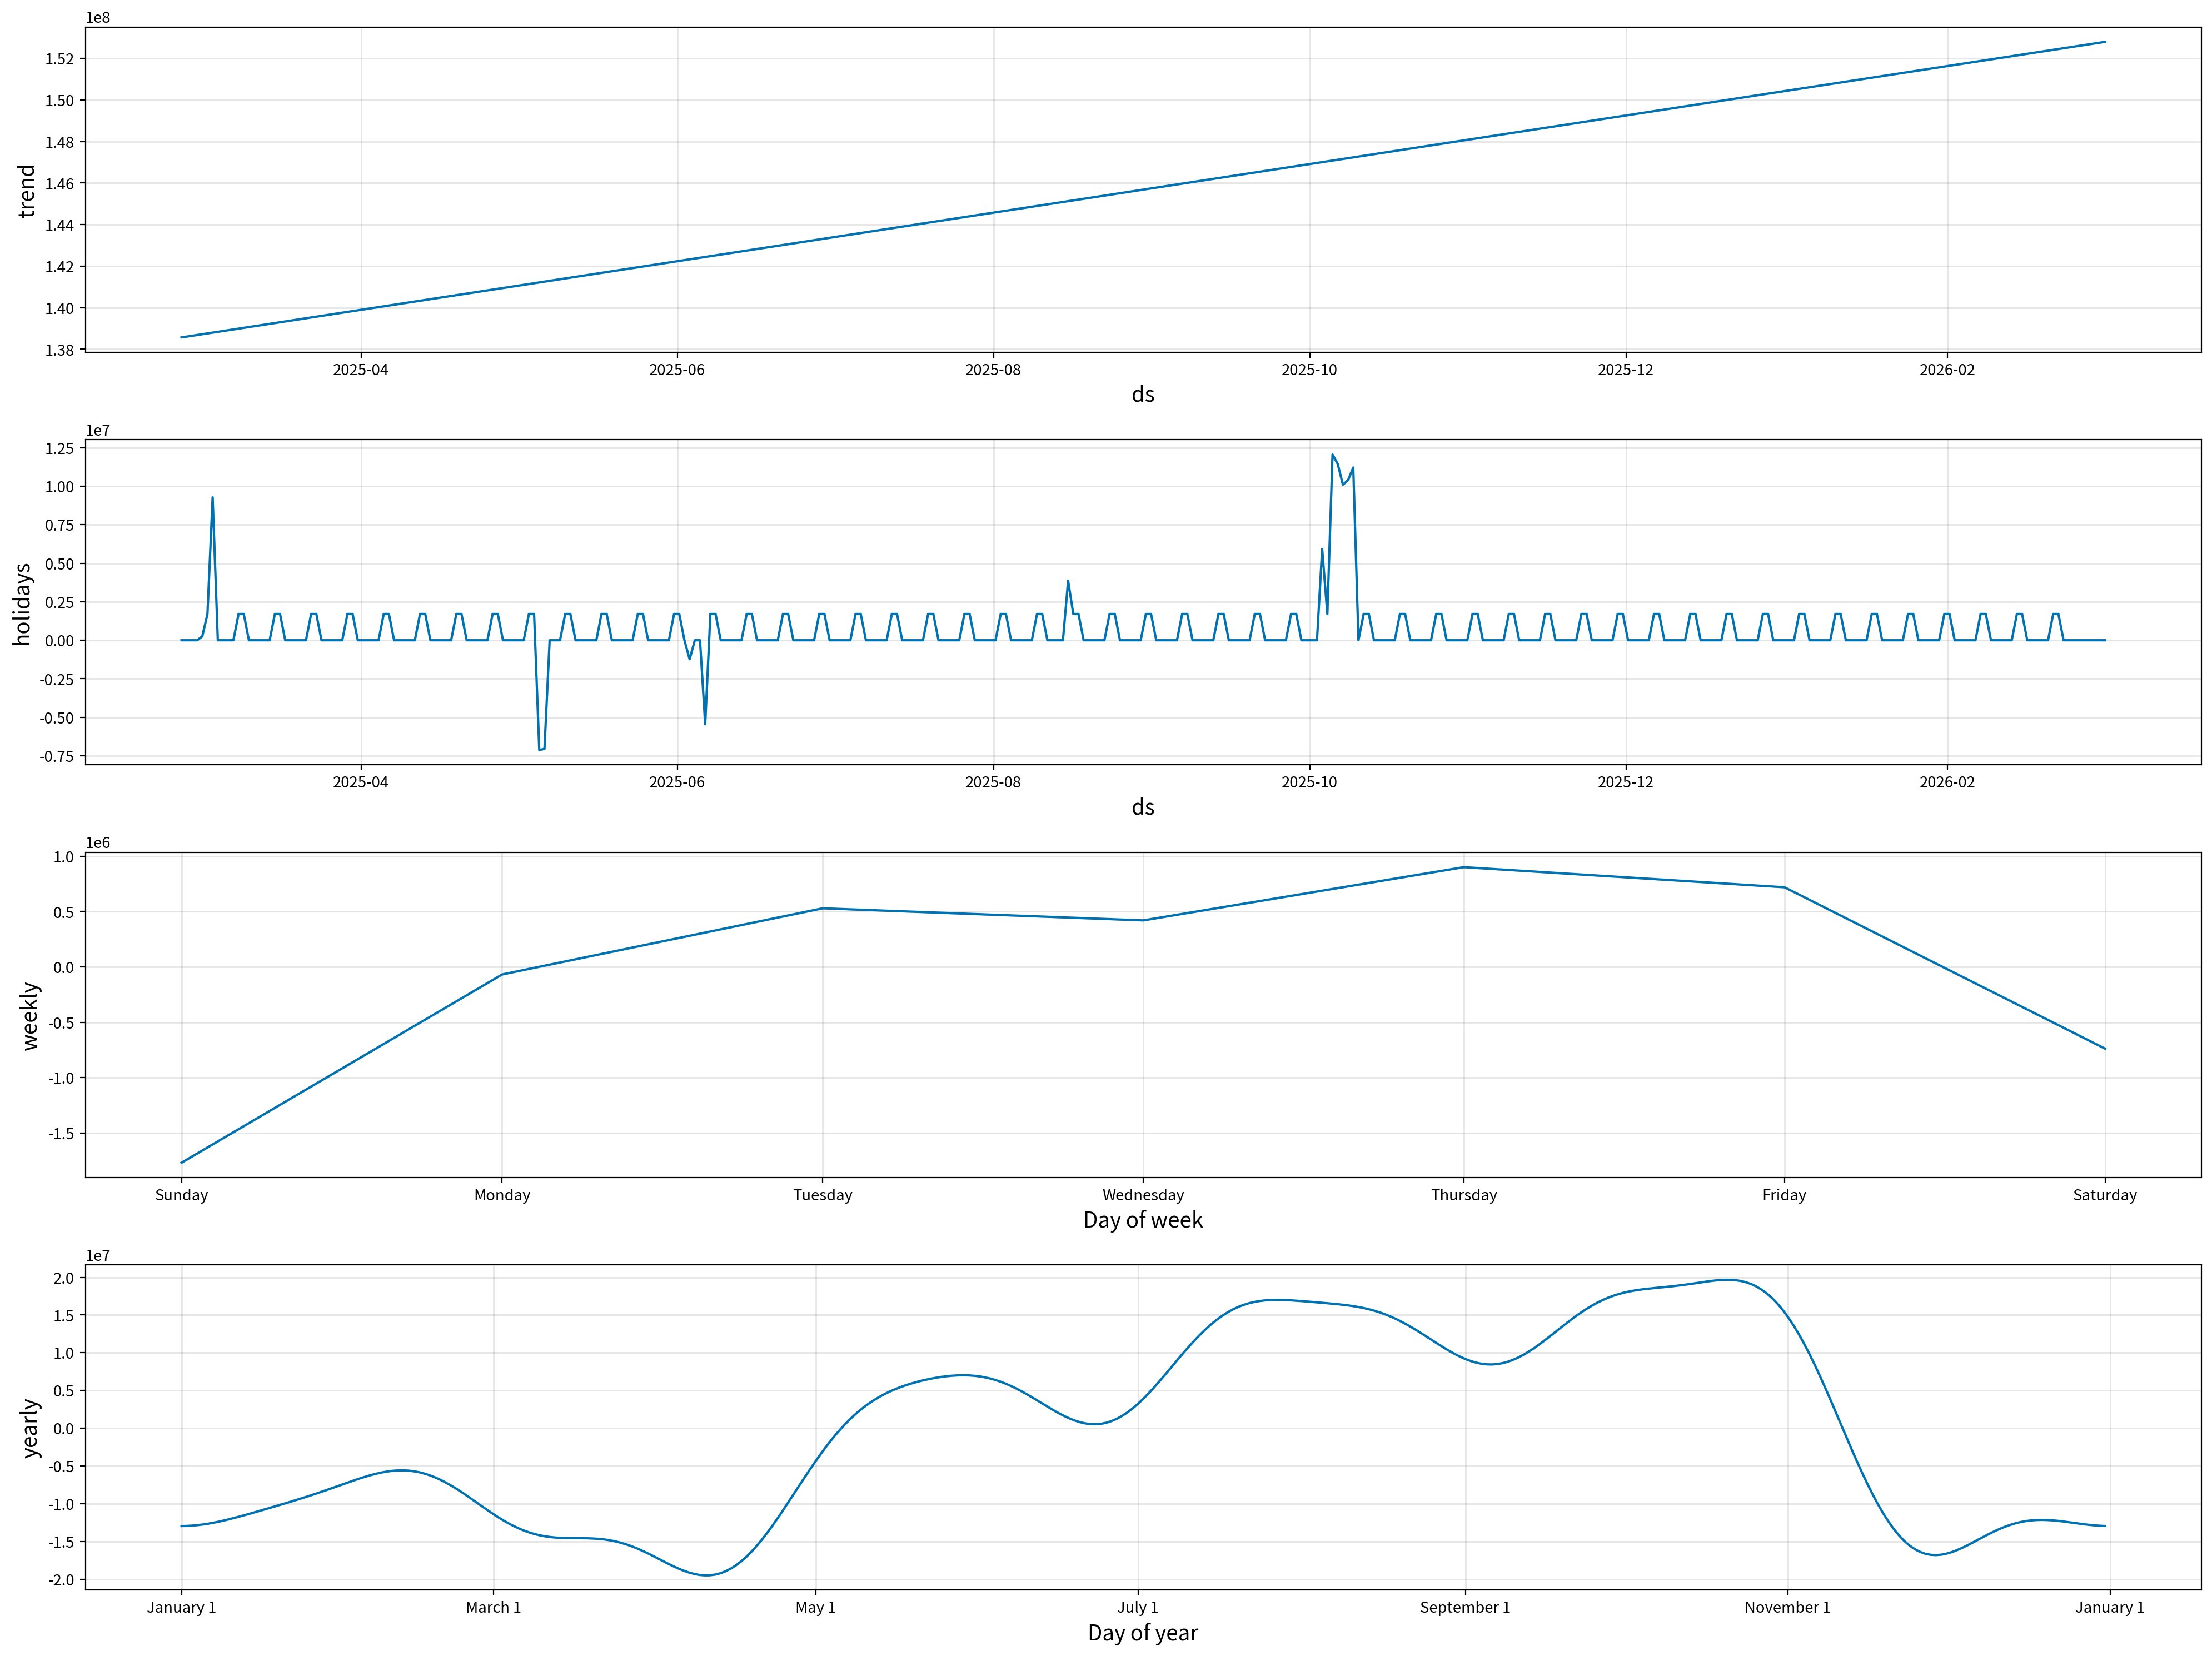

In [36]:
fig = best_model.plot_components(forecast, figsize=(20, 15))
ax = fig.gca()
plt.show()
plt.close()